In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Flatten,Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Rescaling, Dense, Input, GlobalAveragePooling2D, RandomFlip, RandomRotation
import keras_tuner as kt
from model import build_model,build_cnn_model
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
(train_ds,val_ds) = tf.keras.preprocessing.image_dataset_from_directory(
    './data',
    validation_split=0.2,
    subset="both",
    seed=123,
    batch_size=64,
    image_size=(256,256),
)
split_validation_index = len(val_ds) // 2
test_ds = val_ds.skip(split_validation_index)
val_ds = val_ds.take(split_validation_index)
print(len(train_ds), len(val_ds), len(test_ds))


Found 55448 files belonging to 39 classes.
Using 44359 files for training.
Using 11089 files for validation.
694 87 87


In [3]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names, num_classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl

(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)
(64, 256, 256, 3)
(64,)


2026-08-18 18:23:49.700539: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


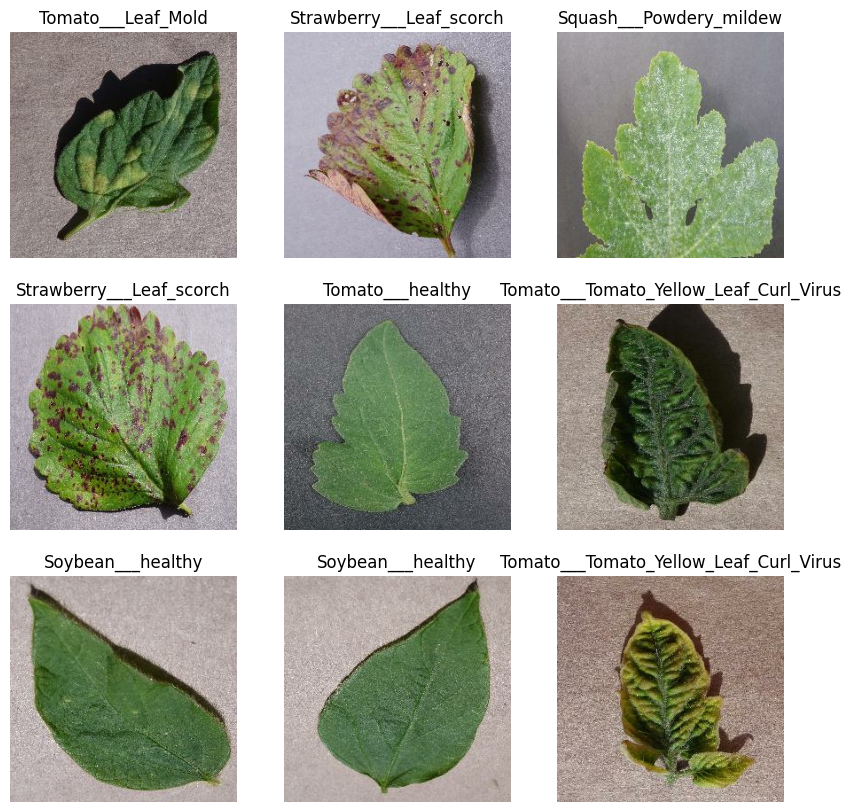

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
  for i in range(9):
    print(images.shape)
    print(labels.shape)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [4]:
# normalize_img = tf.keras.layers.Rescaling(1./255)
def normalize_img(ds, y):
    return tf.cast(ds, tf.float32) / 255., y
# BATCH_SIZE=128

train_ds = train_ds.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE).cache().shuffle(44359).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)


In [5]:
model = build_cnn_model(num_classes)
learning_rate = 0.003
weight_decay = 0.0004
optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate,weight_decay=weight_decay)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy,
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 252, 252, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 252, 252, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 124, 124, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 122, 122, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 122, 122, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 59, 59, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 57, 57, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 57, 57, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 660,807 (2.52 MB)

 Trainable params: 659,399 (2.52 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [7]:
cb = [
    tf.keras.callbacks.ModelCheckpoint(filepath='./best_plant_cnn.keras',
        monitor="val_accuracy", 
        save_best_only=True,
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1),
]
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=20,
  callbacks=[cb]
)

Epoch 1/20


2026-08-18 19:49:05.931761: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:17: Filling up shuffle buffer (this may take a while): 322 of 44359
2026-08-18 19:49:25.953435: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:17: Filling up shuffle buffer (this may take a while): 643 of 44359
2026-08-18 19:49:29.641728: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


 40/694 ━━━━━━━━━━━━━━━━━━━━ 1:31:47 8s/step - accuracy: 0.2420 - loss: 2.8891 - top3_acc: 0.4387

KeyboardInterrupt: 

In [ ]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(history.history['accuracy'], labal="Train Accuracy")
plt.plot(history.history['val_accuracy'], labal="Validation Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], labal="Train Loss")
plt.plot(history.history['val_loss'], labal="Validation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()